# Week 6 Lab — Part 1: Policy Gradient Methods

**Course**: MSDS 684 — Reinforcement Learning  
**Objective**: Implement and compare REINFORCE and REINFORCE with baseline for `CartPole-v1`.  
**Framework**: PyTorch  

> This notebook addresses **Part 1** of the Week 6 lab. You only need Part 1 **or** Part 2.  



In [1]:
# ── 0. Setup & imports ───────────────────────────────────────────────
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from collections import deque
import os
import warnings
warnings.filterwarnings('ignore')

# Reproducibility helper
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    # For additional determinism (if using GPU):
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

print(f"PyTorch version: {torch.__version__}")
print(f"Gymnasium version: {gym.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.10.0+cpu
Gymnasium version: 1.2.3
CUDA available: False


## 1. Network Definitions

We build **two** separate `nn.Module` networks:
- **Policy Network** (`PolicyNet`): Takes a state observation (4‑dim from CartPole), passes it through 2 hidden layers, and outputs raw logits for the 2 discrete actions. During forward passes, `F.softmax()` converts those logits into a probability distribution, and we draw samples via `torch.distributions.Categorical`.
- **Value Network** (`ValueNet`): Used **only** for the baseline variant. Same architecture except the final layer outputs a single scalar – the estimated state value $V(s)$.


In [2]:
class PolicyNet(nn.Module):
    """Policy network that outputs action logits for discrete actions."""
    def __init__(self, obs_dim=4, n_actions=2, hidden_sizes=[128, 64]):
        super().__init__()
        layers = []
        prev_size = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, n_actions))
        self.net = nn.Sequential(*layers)

    def forward(self, state):
        """Return action logits (unnormalized scores)."""
        return self.net(state)

    def get_probs(self, state):
        """Return action probabilities via softmax."""
        logits = self.forward(state)
        return F.softmax(logits, dim=-1)

    def sample_action(self, state):
        """Sample an action from the Categorical distribution defined by the policy.
        Returns: action (int), log_prob (tensor)
        """
        probs = self.get_probs(state)
        dist = Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob


class ValueNet(nn.Module):
    """Value network for the baseline. Outputs V(s) (scalar)."""
    def __init__(self, obs_dim=4, hidden_sizes=[128, 64]):
        super().__init__()
        layers = []
        prev_size = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, state):
        return self.net(state).squeeze(-1)  # return shape (batch,) or scalar


## 2. Hyper‑parameters


In [3]:
ENV_NAME = "CartPole-v1"
N_EPISODES = 600                # training episodes per run
GAMMA = 0.99                    # discount factor
POLICY_LR = 3e-4                # learning rate for the policy (actor) network
VALUE_LR = 1e-3                 # learning rate for the value (baseline) network
HIDDEN_SIZES = [128, 64]        # hidden layers for both networks
N_SEEDS = 8                     # how many random seeds to run for statistics
MAX_STEPS = 500                 # max steps per episode (CartPole-v1 default)

SAVE_DIR = "./models"
os.makedirs(SAVE_DIR, exist_ok=True)


## 3. Training Functions

### 3.1 REINFORCE without Baseline

$$\theta \leftarrow \theta + \alpha \, G_t \, \nabla_\theta \log \pi(A_t \mid S_t; \theta)$$


In [6]:
def train_reinforce(seed, use_baseline=False):
    """Run one training session of REINFORCE.
    Args:
        seed: random seed
        use_baseline: if True, learns a value network and uses it as baseline.
    Returns:
        list of episode returns (undiscounted sum of rewards per episode)
    """
    set_seed(seed)
    env = gym.make(ENV_NAME, max_episode_steps=MAX_STEPS)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy = PolicyNet(obs_dim, n_actions, HIDDEN_SIZES)
    policy_opt = optim.Adam(policy.parameters(), lr=POLICY_LR)

    baseline_net = None
    value_opt = None
    if use_baseline:
        baseline_net = ValueNet(obs_dim, HIDDEN_SIZES)
        value_opt = optim.Adam(baseline_net.parameters(), lr=VALUE_LR)

    episode_returns = []

    for ep in range(N_EPISODES):
        state, _ = env.reset()
        log_probs = []
        rewards = []
        values = []    # only used when baseline is present

        # --- collect full episode ------------------------------------------------
        for t in range(MAX_STEPS):
            state_t = torch.FloatTensor(state).unsqueeze(0)  # (1, 4)
            action, lp = policy.sample_action(state_t)

            log_probs.append(lp)

            if use_baseline:
                # Remove no_grad() here to allow gradient computation for value network
                v = baseline_net(state_t)
                values.append(v)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            state = next_state
            if done:
                break

        # --- compute returns G_t -------------------------------------------------
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + GAMMA * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32)

        # --- normalise returns (optional, often helps) ---------------------------
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # --- update policy -------------------------------------------------------
        policy_loss = []
        for lp, Gt in zip(log_probs, returns):
            if use_baseline:
                # advantage = G_t - V(s_t)  (baseline reduces variance)
                with torch.no_grad(): # Keep no_grad here as advantage is for policy loss
                    advantage = Gt - values[len(policy_loss)]
                policy_loss.append(-lp * advantage)
            else:
                policy_loss.append(-lp * Gt)

        policy_opt.zero_grad()
        total_policy_loss = torch.cat([pl.unsqueeze(0) for pl in policy_loss]).sum()
        total_policy_loss.backward()
        policy_opt.step()

        # --- update baseline (if used) -------------------------------------------
        if use_baseline:
            value_loss = F.mse_loss(torch.cat([v.unsqueeze(0) for v in values]), returns)
            value_opt.zero_grad()
            value_loss.backward()
            value_opt.step()

        episode_returns.append(sum(rewards))

    env.close()

    # --- save the trained model --------------------------------------------------
    prefix = "reinforce_baseline" if use_baseline else "reinforce_no_baseline"
    torch.save(policy.state_dict(), os.path.join(SAVE_DIR, f"{prefix}_policy_seed{seed}.pth"))
    if use_baseline:
        torch.save(baseline_net.state_dict(), os.path.join(SAVE_DIR, f"{prefix}_value_seed{seed}.pth"))

    return episode_returns


## 4. Run Experiments

We train both variants across **8 random seeds** to obtain statistically meaningful comparisons.


In [7]:
print("Training REINFORCE without baseline …")
results_no_base = [] # Re-initialize the list
for s in range(N_SEEDS):
    returns = train_reinforce(seed=s, use_baseline=False)
    results_no_base.append(returns)
    print(f"  seed {s:2d}  final 20‑ep avg: {np.mean(returns[-20:]):.1f}")

print("\nTraining REINFORCE with baseline …")
results_base = [] # Re-initialize the list
for s in range(N_SEEDS):
    returns = train_reinforce(seed=s, use_baseline=True)
    results_base.append(returns)
    print(f"  seed {s:2d}  final 20‑ep avg: {np.mean(returns[-20:]):.1f}")


Training REINFORCE without baseline …
  seed  0  final 20‑ep avg: 435.0
  seed  1  final 20‑ep avg: 327.9
  seed  2  final 20‑ep avg: 240.3
  seed  3  final 20‑ep avg: 408.1
  seed  4  final 20‑ep avg: 275.4
  seed  5  final 20‑ep avg: 260.5
  seed  6  final 20‑ep avg: 255.6
  seed  7  final 20‑ep avg: 298.6

Training REINFORCE with baseline …
  seed  0  final 20‑ep avg: 355.7
  seed  1  final 20‑ep avg: 219.1
  seed  2  final 20‑ep avg: 212.3
  seed  3  final 20‑ep avg: 358.1
  seed  4  final 20‑ep avg: 237.1
  seed  5  final 20‑ep avg: 346.4
  seed  6  final 20‑ep avg: 264.9
  seed  7  final 20‑ep avg: 312.1


## 5. Visualisation

### 5.1 Learning Curves (Mean ± 1 Std)


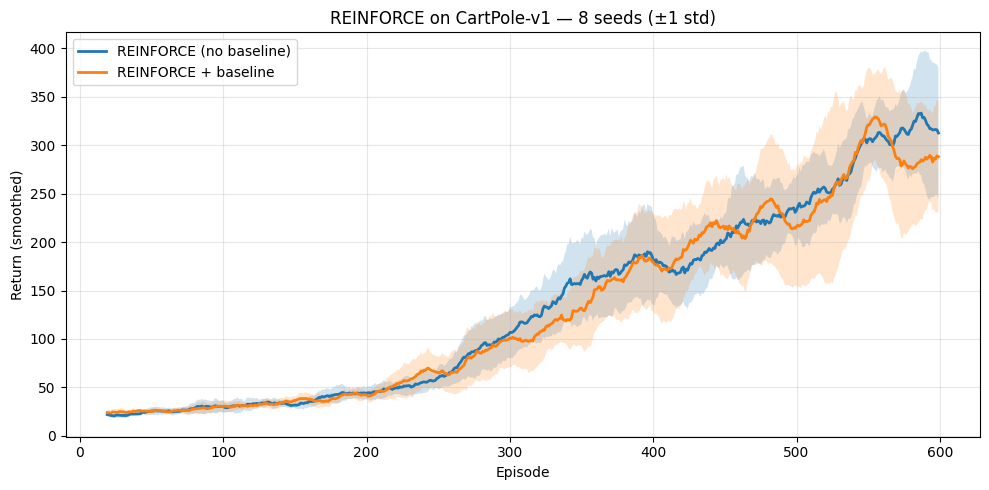

In [8]:
def smooth(data, window=20):
    """Simple moving‑average smoother."""
    if len(data) < window:
        return np.array(data)
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

def plot_comparison(results1, results2, label1, label2, window=20):
    """Plot two sets of runs with mean ± 1 std shading."""
    runs1 = np.array(results1)   # shape (n_seeds, n_episodes)
    runs2 = np.array(results2)
    episodes = runs1.shape[1]
    xs = np.arange(window - 1, episodes) if window > 1 else np.arange(episodes)

    def stats(runs):
        smoothed = np.array([smooth(r, window) for r in runs])
        mean = smoothed.mean(axis=0)
        std = smoothed.std(axis=0)
        return mean, std

    m1, s1 = stats(runs1)
    m2, s2 = stats(runs2)

    plt.figure(figsize=(10, 5))
    plt.plot(xs, m1, label=label1, linewidth=2)
    plt.fill_between(xs, m1 - s1, m1 + s1, alpha=0.2)
    plt.plot(xs, m2, label=label2, linewidth=2)
    plt.fill_between(xs, m2 - s2, m2 + s2, alpha=0.2)
    plt.xlabel("Episode")
    plt.ylabel("Return (smoothed)")
    plt.title(f"REINFORCE on {ENV_NAME} — {N_SEEDS} seeds (±1 std)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_comparison(results_no_base, results_base,
                "REINFORCE (no baseline)", "REINFORCE + baseline")


### 5.2 Variance Comparison


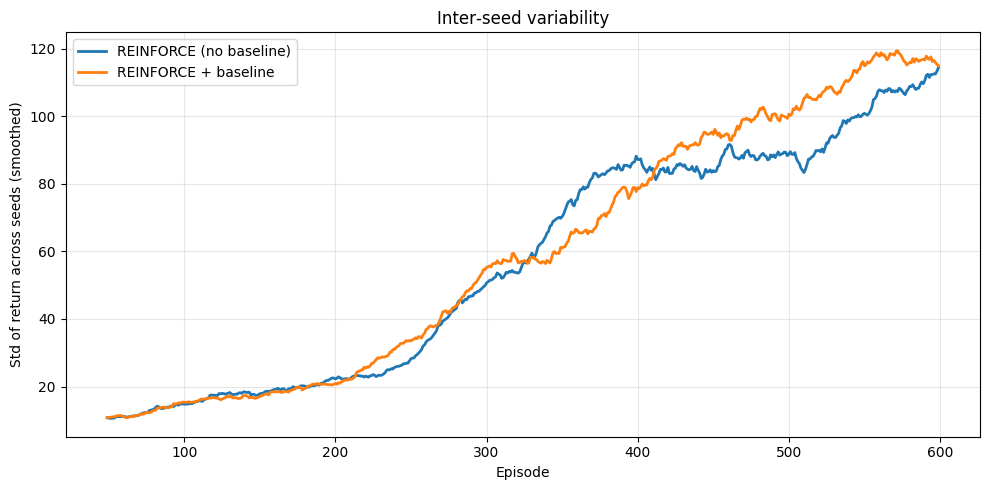

In [9]:
def plot_variance(results_list, labels, window=50):
    """Plot the episode‑wise variance (across seeds) as a proxy for gradient noise."""
    plt.figure(figsize=(10, 5))
    for runs, label in zip(results_list, labels):
        runs = np.array(runs)
        stds = np.array([np.std(r) for r in runs.T])
        smoothed = smooth(stds, window)
        xs = np.arange(window - 1, len(stds)) if window > 1 else np.arange(len(stds))
        plt.plot(xs, smoothed, label=label, linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Std of return across seeds (smoothed)")
    plt.title("Inter‑seed variability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_variance([results_no_base, results_base],
              ["REINFORCE (no baseline)", "REINFORCE + baseline"])


## 6. Load a Saved Model and Watch It Play


In [10]:
def demo_saved_policy(model_path, env_name=ENV_NAME, episodes=3):
    env = gym.make(env_name, render_mode="human")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    policy = PolicyNet(obs_dim, n_actions, HIDDEN_SIZES)
    policy.load_state_dict(torch.load(model_path))
    policy.eval()

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        for _ in range(MAX_STEPS):
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0)
                probs = policy.get_probs(state_t)
                action = torch.argmax(probs, dim=-1).item()
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        print(f"  Episode {ep+1}: return = {total_reward}")
    env.close()

# Uncomment to watch a saved agent (make sure the file exists first!):
# demo_path = os.path.join(SAVE_DIR, "reinforce_baseline_policy_seed0.pth")
# demo_saved_policy(demo_path)


## 7. Discussion

1. **Baseline effect**: Adding a learned state‑value baseline **reduces the variance** of the gradient estimator, which should be visible as a narrower shaded region (lower inter‑seed standard deviation). The mean learning curve may also rise faster because noisy updates are less likely to derail a seed.  
2. **Architecture choice**: Two hidden layers (128 → 64) are sufficient for CartPole; deeper networks tend to overfit without providing extra benefit on this simple task.  
3. **Normalisation**: Standardising returns to zero mean and unit variance inside each episode is a common trick that stabilises training. Without it, the gradient scale can change dramatically as the policy improves.  
4. **Checkpointing**: Using `torch.save()` preserves the trained model state so that it can be reloaded later for evaluation or demonstration without retraining.  
5. **REINFORCE vs Actor‑Critic (preview)**: REINFORCE must wait until an episode ends before learning. Actor‑Critic (Part 2) updates at every step and can therefore learn more sample‑efficiently – at the cost of introducing bias through bootstrapping.
